# 0. Imports & Configs

In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd "/content/drive/MyDrive/Colab-Notebooks/ML4Autism/train/final-project/+ cbam + ghost"

Mounted at /content/drive
/content/drive/MyDrive/Colab-Notebooks/ML4Autism/train/final-project/+ cbam + ghost


In [2]:
# All imports
import torch
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from collections import Counter
import matplotlib.pyplot as plt
import os
import timm
import time
import json

import os, sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from ghost_module import GhostModule
from cbam_module import CBAM

from sklearn.metrics import precision_score, recall_score, confusion_matrix, classification_report
import seaborn as sns
import numpy as np

print(f"CUDA is available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
print(f"cuDNN version: {torch.backends.cudnn.version()}")
print(f"Number of CUDA devices: {torch.cuda.device_count()}")
print(f"Current device: {torch.cuda.current_device()}, Device name: {torch.cuda.get_device_name(0)}")
print(f"Device capability: {torch.cuda.get_device_capability(0)}")
print(f"Device properties: {torch.cuda.get_device_properties(0)}")

CUDA is available: True
CUDA version: 12.8
cuDNN version: 91900
Number of CUDA devices: 1
Current device: 0, Device name: Tesla T4
Device capability: (7, 5)
Device properties: _CudaDeviceProperties(name='Tesla T4', major=7, minor=5, total_memory=14912MB, multi_processor_count=40, uuid=82179246-d7ac-b08b-595b-7af0e5af6e5a, pci_bus_id=0, pci_device_id=4, pci_domain_id=0, L2_cache_size=4MB)


In [3]:
# Configuration: Base folder and paths
BASE_FOLDER = "/content/drive/MyDrive/Colab-Notebooks/ML4Autism/train/"
DATASET_PATH = os.path.join(BASE_FOLDER, "mahmoud-dataset/Images")
MODEL_SAVE_PATH = os.path.join(BASE_FOLDER, "final-project/+ cbam + ghost/convnexttiny_v2")
BEST_MODEL_PATH = os.path.join(MODEL_SAVE_PATH, "best.pth")
BEST_HP_PATH = os.path.join(MODEL_SAVE_PATH, "best_hp.json")

os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

print(f"Base folder: {BASE_FOLDER}")
print(f"Dataset path: {DATASET_PATH}")
print(f"Model save path: {MODEL_SAVE_PATH}")

Base folder: /content/drive/MyDrive/Colab-Notebooks/ML4Autism/train/
Dataset path: /content/drive/MyDrive/Colab-Notebooks/ML4Autism/train/mahmoud-dataset/Images
Model save path: /content/drive/MyDrive/Colab-Notebooks/ML4Autism/train/final-project/+ cbam + ghost/convnexttiny_v2


In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_epochs = 100
pos_weight = torch.tensor([0.67], device=device)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
patience = 12 # Tăng patience để theo dõi kỹ hơn các đợt dao động
lr = 5e-6
weight_decay = 2e-4 # Tăng nhẹ để chống overfitting
max_norm = 0.3 # Giảm max_norm để gradient update mượt hơn

def update_training_phase(model, optimizer, epoch, base_lr):
    """
    Cấu hình Phasing mượt hơn:
    Phase 1 (0-4): Warm-up head (Backbone frozen)
    Phase 2 (5-20): Fine-tune với LR thấp
    Phase 3 (21+): Cực nhỏ để hội tụ sâu
    """
    if epoch < 5:
        for param in model.backbone.parameters():
            param.requires_grad = False
        current_lr = base_lr
    elif epoch < 20:
        for param in model.backbone.parameters():
            param.requires_grad = True
        current_lr = base_lr * 0.5 # Giảm nhẹ so với ban đầu
    else:
        for param in model.backbone.parameters():
            param.requires_grad = True
        current_lr = base_lr * 0.1 # LR rất nhỏ để tinh chỉnh

    for param_group in optimizer.param_groups:
        param_group['lr'] = current_lr
    return current_lr

# 1. Load Data

In [10]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

dataset = datasets.ImageFolder(DATASET_PATH, transform=transform)
targets = [label for _, label in dataset]

train_idx, temp_idx = train_test_split(
    range(len(dataset)),
    test_size=0.3,
    stratify=targets,
    random_state=42,
)

temp_targets = [targets[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.385,
    stratify=temp_targets,
    random_state=42,
)

train_sampler = torch.utils.data.SubsetRandomSampler(train_idx)
val_sampler   = torch.utils.data.SubsetRandomSampler(val_idx)
test_sampler  = torch.utils.data.SubsetRandomSampler(test_idx)

batch_size = 32

train_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, sampler=train_sampler)
val_loader   = torch.utils.data.DataLoader(dataset, batch_size=batch_size, sampler=val_sampler)
test_loader  = torch.utils.data.DataLoader(dataset, batch_size=batch_size, sampler=test_sampler)

print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
print(f"Train batches: {len(train_loader)},  Val batches: {len(val_loader)},   Test batches: {len(test_loader)}")

Train samples: 382, Val samples: 101, Test samples: 64
Train batches: 12,  Val batches: 4,   Test batches: 2


In [11]:
def count_classes(indices, dataset):
    labels = [dataset.samples[i][1] for i in indices]
    return Counter(labels)

print("Class mapping:", dataset.class_to_idx)
print("Train class count:", count_classes(train_idx, dataset))
print("Val class count:  ", count_classes(val_idx, dataset))
print("Test class count: ", count_classes(test_idx, dataset))

Class mapping: {'ASD': 0, 'non-ASD': 1}
Train class count: Counter({1: 229, 0: 153})
Val class count:   Counter({1: 61, 0: 40})
Test class count:  Counter({1: 38, 0: 26})


# 2. Augment Data

In [6]:
def augment_pre_fmmix1(images, labels):
    B = images.size(0)
    flip_mask = torch.rand(B, device=images.device) < 0.5
    for i in range(B):
        if flip_mask[i]:
            images[i] = torch.flip(images[i], dims=[2])
    brightness_delta = torch.empty(B, 1, 1, 1, device=images.device).uniform_(-0.1, 0.1)
    images = images + brightness_delta
    mean = images.mean(dim=(2, 3), keepdim=True)
    contrast_factor = torch.empty(B, 1, 1, 1, device=images.device).uniform_(0.9, 1.1)
    images = (images - mean) * contrast_factor + mean
    images = torch.clamp(images, 0.0, 1.0)
    return images, labels

class Args:
    def __init__(self, alpha=0.05, mask_area_mode=1):
        self.alpha = alpha
        self.mask_area_mode = mask_area_mode

def fmmix1(args, x, target):
    B, C, H, W = x.shape
    shuffle_idx = torch.randperm(B)
    x_shuffle = x[shuffle_idx]
    max_val_indices = torch.argmax(x_shuffle.view(B, C, -1), dim=2)
    max_indices_unraveled = torch.stack((max_val_indices // W, max_val_indices % W), dim=-1)

    lambdas = torch.sqrt(args.alpha * torch.rand(B, 1, 1, 1, device=x.device))
    Wb = (lambdas * W).squeeze(-1)
    Hb = (lambdas * H).squeeze(-1)

    x_range = torch.arange(W, device=x.device)[None, :].expand(B, C, H, W)
    y_range = torch.arange(H, device=x.device)[:, None].expand(B, C, H, W)
    x_min = torch.clamp(max_indices_unraveled[..., 1][..., None, None] - Wb[..., None] // 2, 0, W)
    y_min = torch.clamp(max_indices_unraveled[..., 0][..., None, None] - Hb[..., None] // 2, 0, H)
    x_max = torch.clamp(x_min + Wb[..., None], 0, W)
    y_max = torch.clamp(y_min + Hb[..., None], 0, H)
    masks = (x_range >= x_min) & (x_range < x_max) & (y_range >= y_min) & (y_range < y_max)
    x = x*~masks + x_shuffle*masks

    target_shuffled = target[shuffle_idx]
    p_src = torch.sum(masks, dim=[1,2,3])/(C*W*H)
    p_tar = 1 - p_src
    return x, [2, [p_tar, p_src], [target, target_shuffled]]

In [7]:
args=Args(alpha=0.01)

# Phương án 1: GhostModule Head + CBAM

CBAM được đặt sau backbone để refine features trước khi vào GhostModule head.

## Build Model - PA1 + CBAM

In [8]:
class ModelPA1_CBAM(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model("convnextv2_tiny.fcmae", pretrained=True, num_classes=0, global_pool="")

        # CBAM sau backbone
        in_features = self.backbone.num_features
        self.cbam = CBAM(in_features, reduction=16)

        self.gap = torch.nn.AdaptiveAvgPool2d(1)

        # GhostModule head
        mid_features = in_features // 2
        self.ghost_head = torch.nn.Sequential(
            GhostModule(in_features, mid_features, kernel_size=1, ratio=2),
            torch.nn.ReLU(inplace=True),
            torch.nn.Linear(mid_features, 1)
        )

    def forward(self, x):
        x = self.backbone.forward_features(x)
        x = self.cbam(x)  # CBAM refine features
        x = self.gap(x).flatten(1)
        x = x.unsqueeze(-1).unsqueeze(-1)
        x = self.ghost_head[0](x)
        x = x.flatten(1)
        x = self.ghost_head[1](x)
        x = self.ghost_head[2](x)
        return x

model_pa1 = ModelPA1_CBAM().to(device)
print(f"PA1+CBAM Model. Features: {model_pa1.backbone.num_features}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/111M [00:00<?, ?B/s]

PA1+CBAM Model. Features: 768


## Train Model - PA1 + CBAM

In [24]:
optimizer_pa1 = torch.optim.Adam(model_pa1.parameters(), lr=lr, weight_decay=weight_decay)
scheduler_pa1 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_pa1, T_max=100, eta_min=1e-7)

best_val_loss_pa1 = float('inf')
patience_counter_pa1 = 0
train_losses_pa1, val_losses_pa1 = [], []
train_accs_pa1, val_accs_pa1 = [], []
args = Args(alpha=0.5)

for epoch in range(num_epochs):
    current_lr = update_training_phase(model_pa1, optimizer_pa1, epoch, lr)
    model_pa1.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device).float()
        optimizer_pa1.zero_grad()

        images_fm, labels_fm = augment_pre_fmmix1(images.clone(), labels.clone())
        images_fm, computation = fmmix1(args, images_fm, labels_fm)
        _, (p_tar, p_src), (y, y_shuf) = computation
        y, y_shuf = y.float(), y_shuf.float()

        outputs = model_pa1(images_fm).squeeze(1)

        loss_tar = torch.nn.functional.binary_cross_entropy_with_logits(outputs, y, pos_weight=pos_weight, reduction="none")
        loss_src = torch.nn.functional.binary_cross_entropy_with_logits(outputs, y_shuf, pos_weight=pos_weight, reduction="none")
        loss = (p_tar * loss_tar + p_src * loss_src).mean()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_pa1.parameters(), max_norm=max_norm)
        optimizer_pa1.step()

        with torch.no_grad():
            preds = (outputs > 0).int()
            acc = (p_tar * (preds == y.int()).float() + p_src * (preds == y_shuf.int()).float()).sum().item()
            train_correct += acc
        train_loss += loss.item()
        train_total += (p_tar + p_src).sum().item()

    train_acc = train_correct / train_total
    train_loss /= len(train_loader)
    train_accs_pa1.append(train_acc);
    train_losses_pa1.append(train_loss)

    model_pa1.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device).float()
            outputs = model_pa1(images).squeeze(1)
            val_loss += torch.nn.functional.binary_cross_entropy_with_logits(outputs, labels, pos_weight=pos_weight).item()
            val_correct += ((torch.sigmoid(outputs) > 0.5).int() == labels.int()).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    val_loss /= len(val_loader)
    val_accs_pa1.append(val_acc);
    val_losses_pa1.append(val_loss)

    print(f"[PA1] Epoch {epoch+1} | Train: Loss={train_loss:.4f} Acc={train_acc:.4f} | Val: Loss={val_loss:.4f} Acc={val_acc:.4f}")
    scheduler_pa1.step()

    if val_loss < best_val_loss_pa1:
        best_val_loss_pa1 = val_loss
        torch.save(model_pa1.state_dict(), os.path.join(MODEL_SAVE_PATH, 'best_pa1.pth'))
        patience_counter_pa1 = 0
        print(f"  ✓ PA1+CBAM best model saved")
    else:
        patience_counter_pa1 += 1
        if patience_counter_pa1 >= patience:
          print(f"PA1+CBAM early stopping at epoch {epoch+1}")
          break


[PA1] Epoch 1 | Train: Loss=0.5425 Acc=0.5742 | Val: Loss=0.4686 Acc=0.7525
  ✓ PA1+CBAM best model saved
[PA1] Epoch 2 | Train: Loss=0.5320 Acc=0.6120 | Val: Loss=0.4610 Acc=0.7228
  ✓ PA1+CBAM best model saved
[PA1] Epoch 3 | Train: Loss=0.5354 Acc=0.6065 | Val: Loss=0.4467 Acc=0.6931
  ✓ PA1+CBAM best model saved
[PA1] Epoch 4 | Train: Loss=0.5407 Acc=0.6057 | Val: Loss=0.4375 Acc=0.6931
  ✓ PA1+CBAM best model saved
[PA1] Epoch 5 | Train: Loss=0.5195 Acc=0.6633 | Val: Loss=0.4540 Acc=0.6931
[PA1] Epoch 6 | Train: Loss=0.5366 Acc=0.6161 | Val: Loss=0.4261 Acc=0.7525
  ✓ PA1+CBAM best model saved
[PA1] Epoch 7 | Train: Loss=0.5208 Acc=0.6318 | Val: Loss=0.4404 Acc=0.7030
[PA1] Epoch 8 | Train: Loss=0.5159 Acc=0.6580 | Val: Loss=0.4455 Acc=0.7129
[PA1] Epoch 9 | Train: Loss=0.5309 Acc=0.6232 | Val: Loss=0.4513 Acc=0.7228
[PA1] Epoch 10 | Train: Loss=0.5259 Acc=0.6284 | Val: Loss=0.4469 Acc=0.7129
[PA1] Epoch 11 | Train: Loss=0.5268 Acc=0.6439 | Val: Loss=0.4290 Acc=0.7327
[PA1] Epoch 

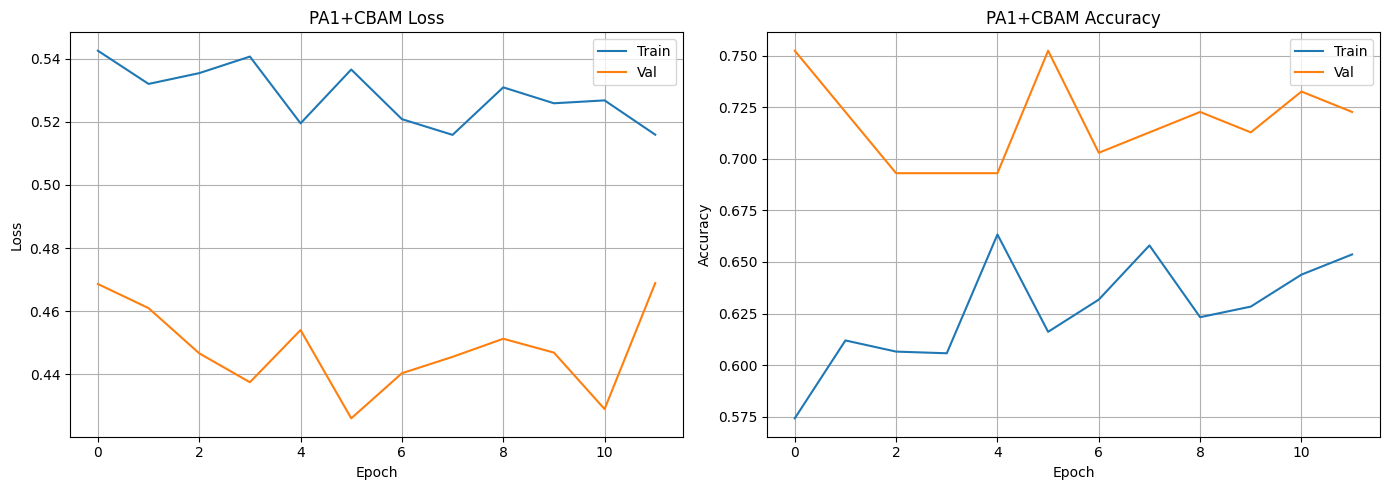

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_losses_pa1, label='Train'); ax1.plot(val_losses_pa1, label='Val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('PA1+CBAM Loss'); ax1.legend(); ax1.grid(True)
ax2.plot(train_accs_pa1, label='Train'); ax2.plot(val_accs_pa1, label='Val')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.set_title('PA1+CBAM Accuracy'); ax2.legend(); ax2.grid(True)
plt.tight_layout(); plt.show()

## Evaluate Model - PA1 + CBAM

[PA1+CBAM] Test Accuracy:  0.7812
[PA1+CBAM] Test Precision: 0.7908
[PA1+CBAM] Test Recall:    0.7812

              precision    recall  f1-score   support

         ASD       0.70      0.81      0.75        26
     non-ASD       0.85      0.76      0.81        38

    accuracy                           0.78        64
   macro avg       0.78      0.79      0.78        64
weighted avg       0.79      0.78      0.78        64



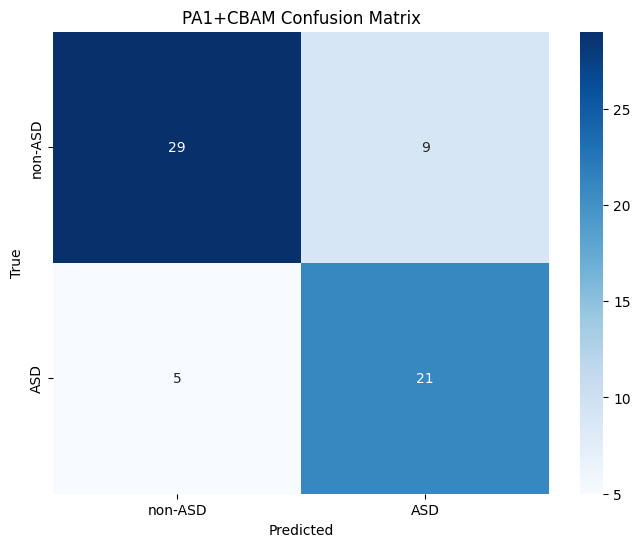

In [26]:
model_pa1.load_state_dict(torch.load(os.path.join(MODEL_SAVE_PATH, 'best_pa1.pth')))
model_pa1.eval()

y_all_pa1, yhat_all_pa1 = [], []
with torch.no_grad():
    for images, labels in test_loader:
        outputs = torch.sigmoid(model_pa1(images.to(device)))
        yhat_all_pa1.extend((outputs > 0.5).int().squeeze(1).cpu().numpy())
        y_all_pa1.extend(labels.numpy())

y_all_pa1, yhat_all_pa1 = np.array(y_all_pa1), np.array(yhat_all_pa1)
accuracy_pa1 = (y_all_pa1 == yhat_all_pa1).mean()
precision_pa1 = precision_score(y_all_pa1, yhat_all_pa1, average='weighted')
recall_pa1 = recall_score(y_all_pa1, yhat_all_pa1, average='weighted')

print(f"[PA1+CBAM] Test Accuracy:  {accuracy_pa1:.4f}")
print(f"[PA1+CBAM] Test Precision: {precision_pa1:.4f}")
print(f"[PA1+CBAM] Test Recall:    {recall_pa1:.4f}")
print("\n" + classification_report(y_all_pa1, yhat_all_pa1, target_names=dataset.classes))

conf_mat_pa1 = confusion_matrix(1 - y_all_pa1, 1 - yhat_all_pa1)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(conf_mat_pa1, annot=True, fmt='g', cmap='Blues', ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title('PA1+CBAM Confusion Matrix')
ax.xaxis.set_ticklabels(['non-ASD', 'ASD']); ax.yaxis.set_ticklabels(['non-ASD', 'ASD'])
plt.show()

# Phương án 2: GhostBottleneck + CBAM

CBAM được đặt giữa ghost1 và ghost2 trong GhostBottleneck để refine intermediate features.

## Build Model - PA2 + CBAM

In [27]:
class GhostBottleneck_CBAM(torch.nn.Module):
    def __init__(self, in_ch, out_ch, expansion=2):
        super().__init__()
        mid_ch = in_ch * expansion
        self.ghost1 = GhostModule(in_ch, mid_ch, kernel_size=1, ratio=2)
        self.cbam = CBAM(mid_ch, reduction=16)  # CBAM giữa 2 ghost
        self.ghost2 = GhostModule(mid_ch, out_ch, kernel_size=1, ratio=2, relu=False)

    def forward(self, x):
        x = self.ghost1(x)
        x = self.cbam(x)  # CBAM attention
        return self.ghost2(x)

class ModelPA2_CBAM(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model("convnextv2_tiny.fcmae", pretrained=True, num_classes=0, global_pool="")
        self.gap = torch.nn.AdaptiveAvgPool2d(1)

        in_features = self.backbone.num_features
        self.ghost_bottleneck = torch.nn.Sequential(
            GhostBottleneck_CBAM(in_features, in_features // 2, expansion=2),
            torch.nn.ReLU(inplace=True),
            GhostBottleneck_CBAM(in_features // 2, in_features // 4, expansion=2),
            torch.nn.ReLU(inplace=True)
        )
        self.head = torch.nn.Linear(in_features // 4, 1)

    def forward(self, x):
        x = self.backbone.forward_features(x)
        x = self.gap(x).flatten(1)
        x = x.unsqueeze(-1).unsqueeze(-1)
        x = self.ghost_bottleneck(x).flatten(1)
        return self.head(x)

model_pa2 = ModelPA2_CBAM().to(device)
print(f"PA2+CBAM Model. Features: {model_pa2.backbone.num_features}")

PA2+CBAM Model. Features: 768


## Train Model - PA2 + CBAM

In [28]:
optimizer_pa2 = torch.optim.AdamW(model_pa2.parameters(), lr=lr, weight_decay=weight_decay)
scheduler_pa2 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_pa2, mode='min', factor=0.5, patience=5)

best_val_loss_pa2 = float('inf')
patience_counter_pa2 = 0
train_losses_pa2, val_losses_pa2, train_accs_pa2, val_accs_pa2 = [], [], [], []
args = Args(alpha=0.5)

for epoch in range(num_epochs):
    current_lr = update_training_phase(model_pa2, optimizer_pa2, epoch, lr)
    model_pa2.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device).float()
        optimizer_pa2.zero_grad()

        images_fm, labels_fm = augment_pre_fmmix1(images.clone(), labels.clone())
        images_fm, computation = fmmix1(args, images_fm, labels_fm)
        _, (p_tar, p_src), (y, y_shuf) = computation
        y, y_shuf = y.float(), y_shuf.float()

        outputs = model_pa2(images_fm).squeeze(1)
        loss_tar = torch.nn.functional.binary_cross_entropy_with_logits(outputs, y, pos_weight=pos_weight, reduction="none")
        loss_src = torch.nn.functional.binary_cross_entropy_with_logits(outputs, y_shuf, pos_weight=pos_weight, reduction="none")
        loss = (p_tar * loss_tar + p_src * loss_src).mean()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_pa2.parameters(), max_norm=max_norm)
        optimizer_pa2.step()

        with torch.no_grad():
            preds = (outputs > 0).int()
            acc = (p_tar * (preds == y.int()).float() + p_src * (preds == y_shuf.int()).float()).sum().item()
            train_correct += acc
        train_loss += loss.item()
        train_total += (p_tar + p_src).sum().item()

    train_acc = train_correct / train_total
    train_loss /= len(train_loader)

    model_pa2.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device).float()
            outputs = model_pa2(images).squeeze(1)
            val_loss += torch.nn.functional.binary_cross_entropy_with_logits(outputs, labels, pos_weight=pos_weight).item()
            val_correct += ((outputs > 0).int() == labels.int()).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    val_loss /= len(val_loader)
    train_losses_pa2.append(train_loss);
    val_losses_pa2.append(val_loss)
    train_accs_pa2.append(train_acc);
    val_accs_pa2.append(val_acc)

    print(f"[PA2] Epoch {epoch+1} | LR: {current_lr:.7f} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
    scheduler_pa2.step(val_loss)

    if val_loss < best_val_loss_pa2:
        best_val_loss_pa2 = val_loss
        torch.save(model_pa2.state_dict(), os.path.join(MODEL_SAVE_PATH, 'best_pa2.pth'))
        patience_counter_pa2 = 0
        print(f"  ✓ PA2+CBAM best model saved")
    else:
        patience_counter_pa2 += 1
        if patience_counter_pa2 >= patience:
          print(f"PA2+CBAM early stopping at epoch {epoch+1}")
          break

[PA2] Epoch 1 | LR: 0.0000050 | Train Loss: 0.5926 Acc: 0.3891 | Val Loss: 0.5634 Acc: 0.3960
  ✓ PA2+CBAM best model saved
[PA2] Epoch 2 | LR: 0.0000050 | Train Loss: 0.5716 Acc: 0.4395 | Val Loss: 0.5489 Acc: 0.3960
  ✓ PA2+CBAM best model saved
[PA2] Epoch 3 | LR: 0.0000050 | Train Loss: 0.5628 Acc: 0.4455 | Val Loss: 0.5569 Acc: 0.3960
[PA2] Epoch 4 | LR: 0.0000050 | Train Loss: 0.5564 Acc: 0.4687 | Val Loss: 0.5522 Acc: 0.3960
[PA2] Epoch 5 | LR: 0.0000050 | Train Loss: 0.5405 Acc: 0.5184 | Val Loss: 0.5452 Acc: 0.4059
  ✓ PA2+CBAM best model saved
[PA2] Epoch 6 | LR: 0.0000005 | Train Loss: 0.5621 Acc: 0.4976 | Val Loss: 0.5616 Acc: 0.3960
[PA2] Epoch 7 | LR: 0.0000005 | Train Loss: 0.5538 Acc: 0.5201 | Val Loss: 0.5327 Acc: 0.4554
  ✓ PA2+CBAM best model saved
[PA2] Epoch 8 | LR: 0.0000005 | Train Loss: 0.5402 Acc: 0.5109 | Val Loss: 0.5455 Acc: 0.4851
[PA2] Epoch 9 | LR: 0.0000005 | Train Loss: 0.5564 Acc: 0.4743 | Val Loss: 0.5265 Acc: 0.5446
  ✓ PA2+CBAM best model saved
[PA2

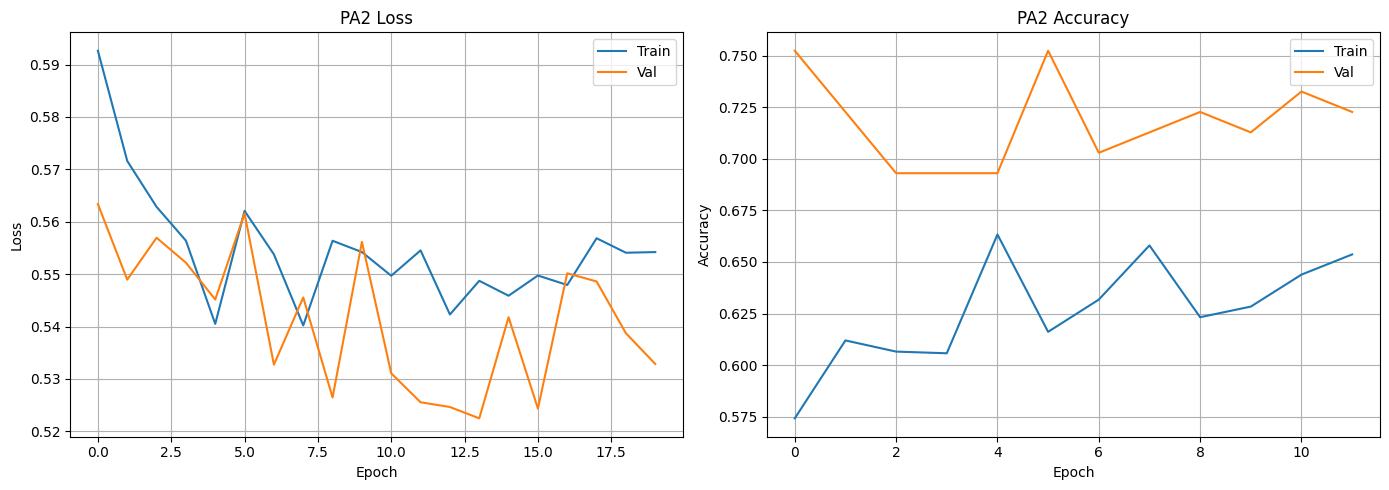

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_losses_pa2, label='Train'); ax1.plot(val_losses_pa2, label='Val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('PA2 Loss'); ax1.legend(); ax1.grid(True)
ax2.plot(train_accs_pa1, label='Train'); ax2.plot(val_accs_pa1, label='Val')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.set_title('PA2 Accuracy'); ax2.legend(); ax2.grid(True)
plt.tight_layout(); plt.show()

## Evaluate Model - PA2 + CBAM

[PA2+CBAM] Test Accuracy:  0.5781
[PA2+CBAM] Test Precision: 0.6878
[PA2+CBAM] Test Recall:    0.5781

              precision    recall  f1-score   support

         ASD       0.49      0.88      0.63        26
     non-ASD       0.82      0.37      0.51        38

    accuracy                           0.58        64
   macro avg       0.66      0.63      0.57        64
weighted avg       0.69      0.58      0.56        64



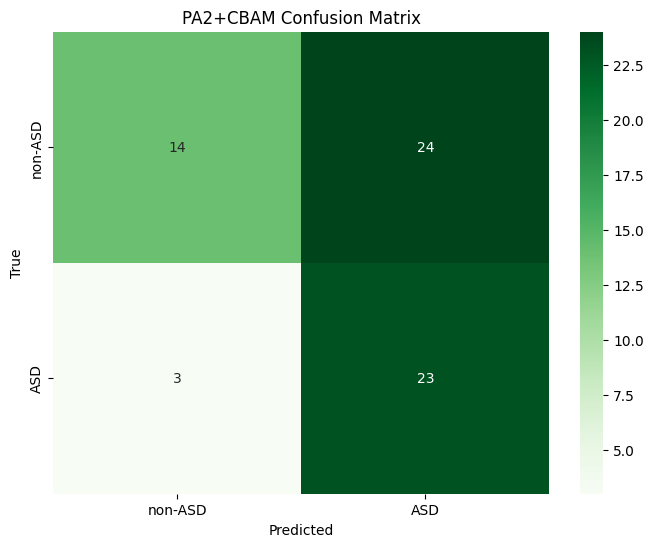

In [30]:
model_pa2.load_state_dict(torch.load(os.path.join(MODEL_SAVE_PATH, 'best_pa2.pth')))
model_pa2.eval()

y_all_pa2, yhat_all_pa2 = [], []
with torch.no_grad():
    for images, labels in test_loader:
        outputs = torch.sigmoid(model_pa2(images.to(device)))
        yhat_all_pa2.extend((outputs > 0.5).int().squeeze(1).cpu().numpy())
        y_all_pa2.extend(labels.numpy())

y_all_pa2, yhat_all_pa2 = np.array(y_all_pa2), np.array(yhat_all_pa2)
accuracy_pa2 = (y_all_pa2 == yhat_all_pa2).mean()
precision_pa2 = precision_score(y_all_pa2, yhat_all_pa2, average='weighted')
recall_pa2 = recall_score(y_all_pa2, yhat_all_pa2, average='weighted')

print(f"[PA2+CBAM] Test Accuracy:  {accuracy_pa2:.4f}")
print(f"[PA2+CBAM] Test Precision: {precision_pa2:.4f}")
print(f"[PA2+CBAM] Test Recall:    {recall_pa2:.4f}")
print("\n" + classification_report(y_all_pa2, yhat_all_pa2, target_names=dataset.classes))

conf_mat_pa2 = confusion_matrix(1 - y_all_pa2, 1 - yhat_all_pa2)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(conf_mat_pa2, annot=True, fmt='g', cmap='Greens', ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title('PA2+CBAM Confusion Matrix')
ax.xaxis.set_ticklabels(['non-ASD', 'ASD']); ax.yaxis.set_ticklabels(['non-ASD', 'ASD'])
plt.show()

# Phương án 3: GhostAdapter + CBAM

CBAM được đặt sau GhostAdapter để refine output features của adapter.

## Build Model - PA3 + CBAM

In [31]:
class GhostAdapter(torch.nn.Module):
    def __init__(self, in_channels, reduction=4):
        super().__init__()
        mid_channels = in_channels // reduction
        self.adapter = torch.nn.Sequential(
            GhostModule(in_channels, mid_channels, kernel_size=1, ratio=2),
            torch.nn.ReLU(inplace=True),
            GhostModule(mid_channels, in_channels, kernel_size=1, ratio=2, relu=False)
        )

    def forward(self, x):
        return x + self.adapter(x)

class ModelPA3_CBAM(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model("convnextv2_tiny.fcmae", pretrained=True, num_classes=0, global_pool="")
        self.gap = torch.nn.AdaptiveAvgPool2d(1)

        in_features = self.backbone.num_features
        self.ghost_adapter = GhostAdapter(in_features, reduction=4)
        self.cbam = CBAM(in_features, reduction=16)  # CBAM sau adapter
        self.head = torch.nn.Linear(in_features, 1)

    def forward(self, x):
        x = self.backbone.forward_features(x)
        x = self.ghost_adapter(x)
        x = self.cbam(x)  # CBAM refine adapter output
        x = self.gap(x).flatten(1)
        return self.head(x)

model_pa3 = ModelPA3_CBAM().to(device)
print(f"PA3+CBAM Model. Features: {model_pa3.backbone.num_features}")

PA3+CBAM Model. Features: 768


## Train Model - PA3 + CBAM

In [32]:
optimizer_pa3 = torch.optim.Adam(model_pa3.parameters(), lr=lr, weight_decay=weight_decay)
scheduler_pa3 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_pa3, T_max=100, eta_min=1e-6)

best_val_loss_pa3 = float('inf')
patience_counter_pa3 = 0
train_losses_pa3, val_losses_pa3, train_accs_pa3, val_accs_pa3 = [], [], [], []
args = Args(alpha=0.5)

for epoch in range(num_epochs):
    current_lr = update_training_phase(model_pa3, optimizer_pa3, epoch, lr)
    model_pa3.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device).float()
        optimizer_pa3.zero_grad()

        images_fm, labels_fm = augment_pre_fmmix1(images.clone(), labels.clone())
        images_fm, computation = fmmix1(args, images_fm, labels_fm)
        _, (p_tar, p_src), (y, y_shuf) = computation
        y, y_shuf = y.float(), y_shuf.float()

        outputs = model_pa3(images_fm).squeeze(1)
        loss_tar = torch.nn.functional.binary_cross_entropy_with_logits(outputs, y, pos_weight=pos_weight, reduction="none")
        loss_src = torch.nn.functional.binary_cross_entropy_with_logits(outputs, y_shuf, pos_weight=pos_weight, reduction="none")
        loss = (p_tar * loss_tar + p_src * loss_src).mean()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_pa3.parameters(), max_norm=max_norm)
        optimizer_pa3.step()

        with torch.no_grad():
            preds = (outputs > 0).int()
            acc = (p_tar * (preds == y.int()).float() + p_src * (preds == y_shuf.int()).float()).sum().item()
            train_correct += acc
        train_loss += loss.item()
        train_total += (p_tar + p_src).sum().item()

    train_acc = train_correct / train_total
    train_loss /= len(train_loader)

    model_pa3.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device).float()
            outputs = model_pa3(images).squeeze(1)
            val_loss += torch.nn.functional.binary_cross_entropy_with_logits(outputs, labels, pos_weight=pos_weight).item()
            val_correct += ((torch.sigmoid(outputs) > 0.5).int() == labels.int()).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    val_loss /= len(val_loader)
    train_losses_pa3.append(train_loss); val_losses_pa3.append(val_loss)
    train_accs_pa3.append(train_acc); val_accs_pa3.append(val_acc)

    print(f"[PA3] Epoch {epoch+1} | Train: Loss={train_loss:.4f} Acc={train_acc:.4f} | Val: Loss={val_loss:.4f} Acc={val_acc:.4f}")
    scheduler_pa3.step()

    if val_loss < best_val_loss_pa3:
        best_val_loss_pa3 = val_loss
        torch.save(model_pa3.state_dict(), os.path.join(MODEL_SAVE_PATH, 'best_pa3.pth'))
        patience_counter_pa3 = 0
        print(f"  ✓ PA3+CBAM best model saved")
    else:
        patience_counter_pa3 += 1
        if patience_counter_pa3 >= patience:
          print(f"PA3+CBAM early stopping at epoch {epoch+1}")
          break

[PA3] Epoch 1 | Train: Loss=0.5619 Acc=0.4043 | Val: Loss=0.5551 Acc=0.6337
  ✓ PA3+CBAM best model saved
[PA3] Epoch 2 | Train: Loss=0.5598 Acc=0.4000 | Val: Loss=0.5557 Acc=0.6040
[PA3] Epoch 3 | Train: Loss=0.5578 Acc=0.4291 | Val: Loss=0.5652 Acc=0.4158
[PA3] Epoch 4 | Train: Loss=0.5566 Acc=0.3932 | Val: Loss=0.5727 Acc=0.3960
[PA3] Epoch 5 | Train: Loss=0.5579 Acc=0.4273 | Val: Loss=0.5615 Acc=0.3960
[PA3] Epoch 6 | Train: Loss=0.5557 Acc=0.4285 | Val: Loss=0.5479 Acc=0.4554
  ✓ PA3+CBAM best model saved
[PA3] Epoch 7 | Train: Loss=0.5533 Acc=0.4885 | Val: Loss=0.5551 Acc=0.5743
[PA3] Epoch 8 | Train: Loss=0.5505 Acc=0.5598 | Val: Loss=0.5476 Acc=0.6436
  ✓ PA3+CBAM best model saved
[PA3] Epoch 9 | Train: Loss=0.5492 Acc=0.6006 | Val: Loss=0.5393 Acc=0.6832
  ✓ PA3+CBAM best model saved
[PA3] Epoch 10 | Train: Loss=0.5478 Acc=0.5705 | Val: Loss=0.5208 Acc=0.7129
  ✓ PA3+CBAM best model saved
[PA3] Epoch 11 | Train: Loss=0.5465 Acc=0.5468 | Val: Loss=0.5230 Acc=0.7327
[PA3] Epoch 

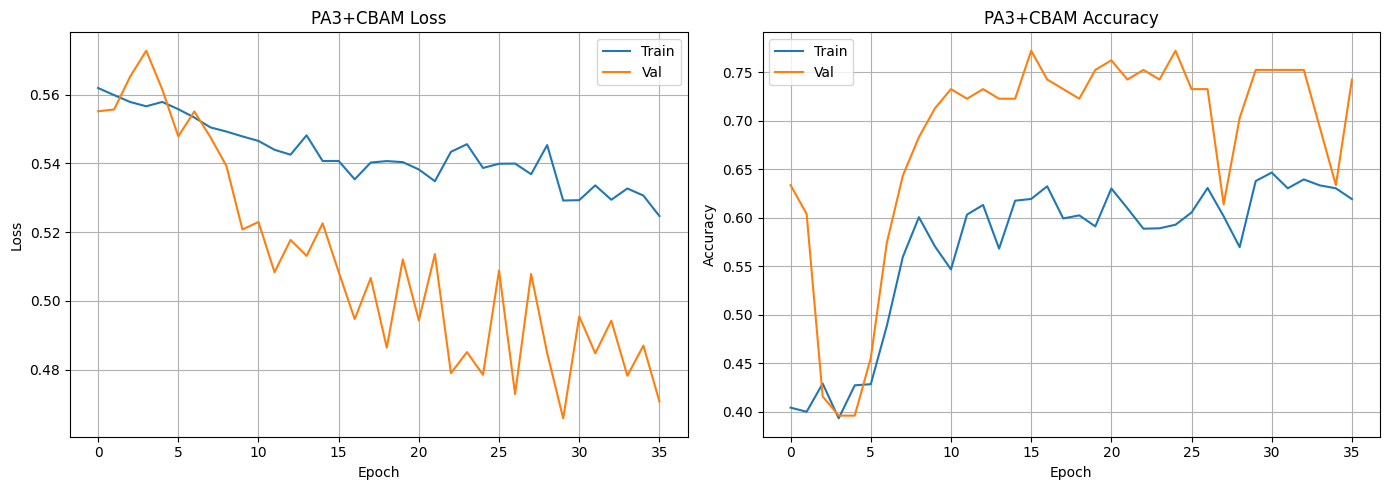

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_losses_pa3, label='Train'); ax1.plot(val_losses_pa3, label='Val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('PA3+CBAM Loss'); ax1.legend(); ax1.grid(True)
ax2.plot(train_accs_pa3, label='Train'); ax2.plot(val_accs_pa3, label='Val')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.set_title('PA3+CBAM Accuracy'); ax2.legend(); ax2.grid(True)
plt.tight_layout(); plt.show()

## Evaluate Model - PA3 + CBAM

[PA3+CBAM] Test Accuracy:  0.7812
[PA3+CBAM] Test Precision: 0.7804
[PA3+CBAM] Test Recall:    0.7812

              precision    recall  f1-score   support

         ASD       0.77      0.65      0.71        26
     non-ASD       0.79      0.87      0.82        38

    accuracy                           0.78        64
   macro avg       0.78      0.76      0.77        64
weighted avg       0.78      0.78      0.78        64



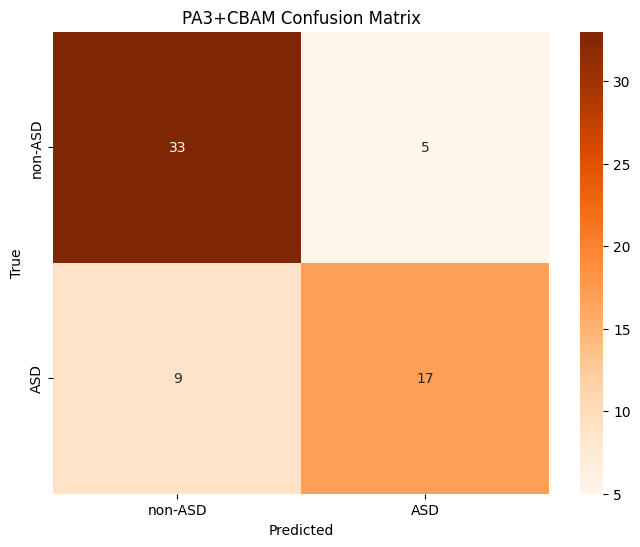

In [34]:
model_pa3.load_state_dict(torch.load(os.path.join(MODEL_SAVE_PATH, 'best_pa3.pth')))
model_pa3.eval()

y_all_pa3, yhat_all_pa3 = [], []
with torch.no_grad():
    for images, labels in test_loader:
        outputs = torch.sigmoid(model_pa3(images.to(device)))
        yhat_all_pa3.extend((outputs > 0.5).int().squeeze(1).cpu().numpy())
        y_all_pa3.extend(labels.numpy())

y_all_pa3, yhat_all_pa3 = np.array(y_all_pa3), np.array(yhat_all_pa3)
accuracy_pa3 = (y_all_pa3 == yhat_all_pa3).mean()
precision_pa3 = precision_score(y_all_pa3, yhat_all_pa3, average='weighted')
recall_pa3 = recall_score(y_all_pa3, yhat_all_pa3, average='weighted')

print(f"[PA3+CBAM] Test Accuracy:  {accuracy_pa3:.4f}")
print(f"[PA3+CBAM] Test Precision: {precision_pa3:.4f}")
print(f"[PA3+CBAM] Test Recall:    {recall_pa3:.4f}")
print("\n" + classification_report(y_all_pa3, yhat_all_pa3, target_names=dataset.classes))

conf_mat_pa3 = confusion_matrix(1 - y_all_pa3, 1 - yhat_all_pa3)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(conf_mat_pa3, annot=True, fmt='g', cmap='Oranges', ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title('PA3+CBAM Confusion Matrix')
ax.xaxis.set_ticklabels(['non-ASD', 'ASD']); ax.yaxis.set_ticklabels(['non-ASD', 'ASD'])
plt.show()